In [ ]:
Machine Learning
Dataset: Breast Cancer Wisconsin

Core methods:
- Supervised learning learns from labeled examples and includes regression and classification.
- Unsupervised learning finds structure in unlabeled data and includes clustering and
  dimensionality reduction.
- Regression predicts continuous values, like price or demand.
- Classification predicts categories, like benign vs malignant.
- Clustering groups similar observations without labels.
- Time series models ordered data over time and is used for forecasting and sequence analysis.
- Bayesian modeling updates prior beliefs with data to produce probabilistic conclusions and
  uncertainty estimates.

The following algorithms for Conversion Modeling and Ranking
- These algorithms focus on predicting outcomes based on user behavior, optimizing
conversion rates, and ranking items or users effectively.

Algorithm and Description:
- Logistic Regression-A statistical method for predicting binary outcomes based on one
or more predictor variables.
- Decision Trees-A model that uses a tree-like graph of decisions to predict outcomes
based on input features.
- Gradient Boosting-An ensemble technique that builds models sequentially to improve
prediction accuracy.
- Random Forest-An ensemble of decision trees that improves prediction by averaging
multiple trees.

* These algorithms focus on predicting outcomes based on user behavior, optimizing
conversion rates, and ranking items or users effectively.

Visualizations
- The bar chart makes it easy to compare Accuracy, Precision, Recall, F1, and ROC-AUC
  across all models.
- The confusion matrices show which classes each model predicts correctly or confuses.
- The ROC curves show tradeoffs between true positives and false positives, and are
  especially useful for comparing classifiers.

In [1]:
# Install libraries
!pip -q install ucimlrepo

import pandas as pd
import numpy as np

from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay, roc_curve, auc

print ("libraries are ready")

libraries are ready


In [2]:
# Load dataset
dataset = fetch_ucirepo(id=17)  # Breast Cancer Wisconsin (Diagnostic)
X = dataset.data.features
y = dataset.data.targets

print ("dataset is ready")

dataset is ready


In [3]:
# Target cleanup
y = y.iloc[:, 0]
if y.dtype == "object":
    y = y.map({"M": 1, "B": 0})

print ("cleanup complete")

cleanup complete


In [4]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=5000, random_state=42))
    ]),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
    else:
        y_proba = None

    row = {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC_AUC": roc_auc_score(y_test, y_proba) if y_proba is not None else np.nan
    }
    results.append(row)

    print("=" * 80)
    print(name)
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))


Logistic Regression
[[71  1]
 [ 3 39]]
              precision    recall  f1-score   support

           0       0.96      0.99      0.97        72
           1       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114

Decision Tree
[[68  4]
 [ 4 38]]
              precision    recall  f1-score   support

           0       0.94      0.94      0.94        72
           1       0.90      0.90      0.90        42

    accuracy                           0.93       114
   macro avg       0.92      0.92      0.92       114
weighted avg       0.93      0.93      0.93       114

Random Forest
[[72  0]
 [ 3 39]]
              precision    recall  f1-score   support

           0       0.96      1.00      0.98        72
           1       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98

In [5]:
results_df = pd.DataFrame(results).sort_values(by="F1", ascending=False)
print("\nSummary:")
print(results_df)


Summary:
                 Model  Accuracy  Precision    Recall        F1   ROC_AUC
2        Random Forest  0.973684   1.000000  0.928571  0.962963  0.994378
0  Logistic Regression  0.964912   0.975000  0.928571  0.951220  0.996032
3    Gradient Boosting  0.964912   1.000000  0.904762  0.950000  0.994709
1        Decision Tree  0.929825   0.904762  0.904762  0.904762  0.924603


In [6]:
# Save predictions and probabilities for each model
pred_store = {}

for name, model in models.items():
    y_pred = model.predict(X_test)
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
    else:
        y_proba = None
    pred_store[name] = {"y_pred": y_pred, "y_proba": y_proba}
print ("predictions saved")

predictions saved


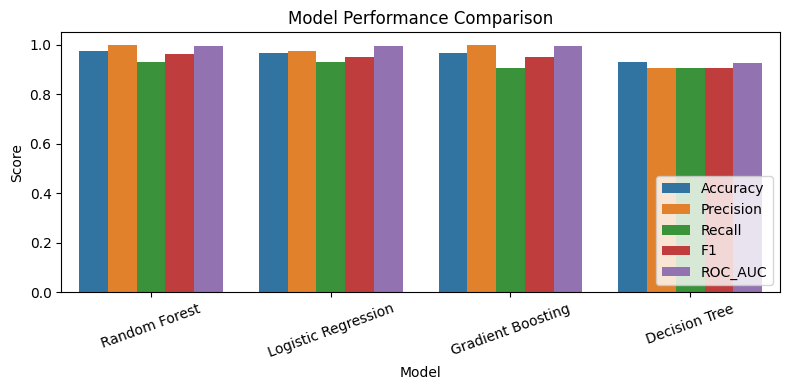

In [13]:
#Visualization: Bar chart: compare model performance
metrics_plot = results_df.copy()
metrics_melt = metrics_plot.melt(id_vars="Model", value_vars=["Accuracy", "Precision", "Recall", "F1", "ROC_AUC"],
                                 var_name="Metric", value_name="Score")

plt.figure(figsize=(8, 4))
sns.barplot(data=metrics_melt, x="Model", y="Score", hue="Metric")
plt.title("Model Performance Comparison")
plt.ylim(0, 1.05)
plt.xticks(rotation=20)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


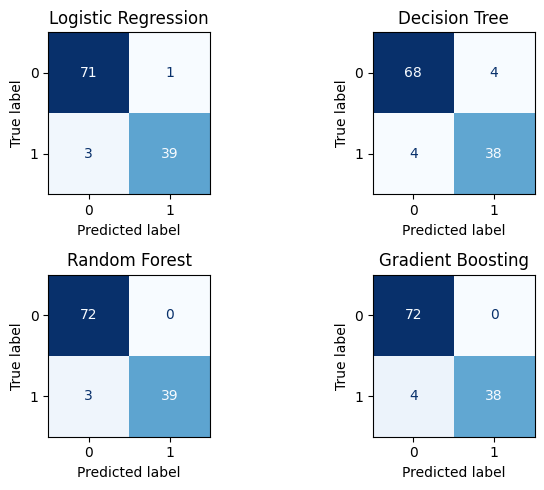

In [12]:
# 2) Confusion matrices
fig, axes = plt.subplots(2, 2, figsize=(7, 5))
axes = axes.ravel()

for ax, (name, preds) in zip(axes, pred_store.items()):
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        preds["y_pred"],
        ax=ax,
        cmap="Blues",
        colorbar=False
    )
    ax.set_title(name)

plt.tight_layout()
plt.show()


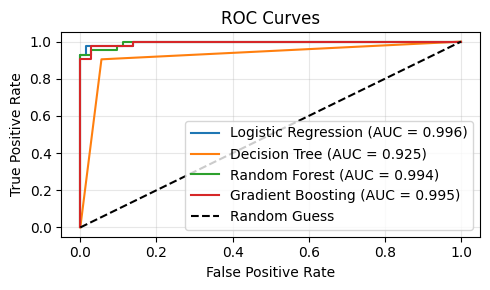

In [10]:
# 3) ROC curves
plt.figure(figsize=(5, 3))

for name, preds in pred_store.items():
    if preds["y_proba"] is not None:
        fpr, tpr, _ = roc_curve(y_test, preds["y_proba"])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], "k--", label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()